## Lab 1
## Name: Arnish Manwatkar
## Batch: C-C3
## Roll no: 38
## ML Lab

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [45]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [47]:
df.shape

(891, 12)

In [48]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [50]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [51]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [52]:
# if lots of outliers-> median;if opposite then mean

In [53]:
#handling missing
df["Age"].fillna(df["Age"].median(), inplace=True)

In [54]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

In [55]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [56]:
df.drop("Cabin",axis=1,inplace=True)

In [57]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(0)

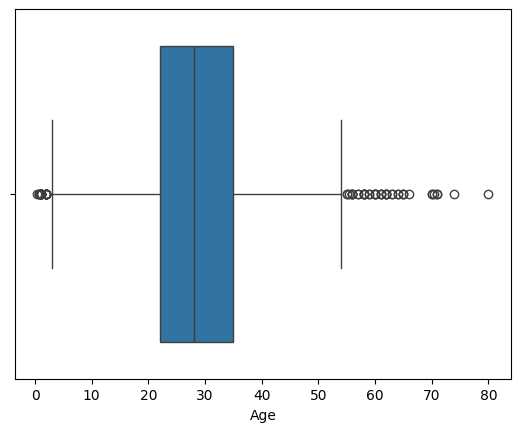

In [59]:
sns.boxplot(x=df["Age"])
plt.show()

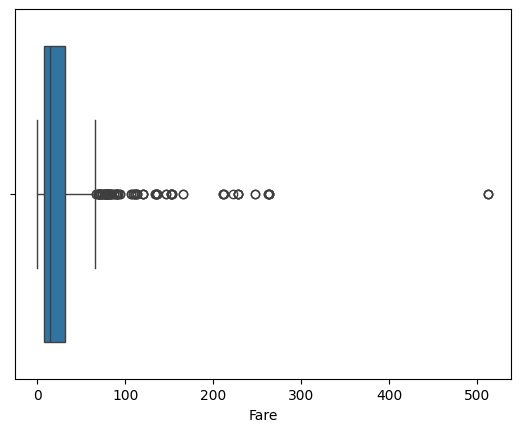

In [60]:
sns.boxplot(x=df["Fare"])
plt.show()

In [61]:
Q1=df["Age"].quantile(0.25)
Q3=df["Age"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[(df["Age"]>=lower) & (df["Age"]<=upper)]

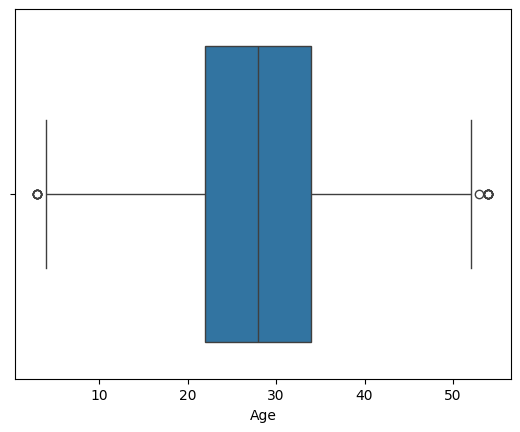

In [62]:
sns.boxplot(x=df["Age"])
plt.show()

In [63]:
Q1=df["Fare"].quantile(0.25)
Q3=df["Fare"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[(df["Fare"]>=lower) & (df["Fare"]<=upper)]

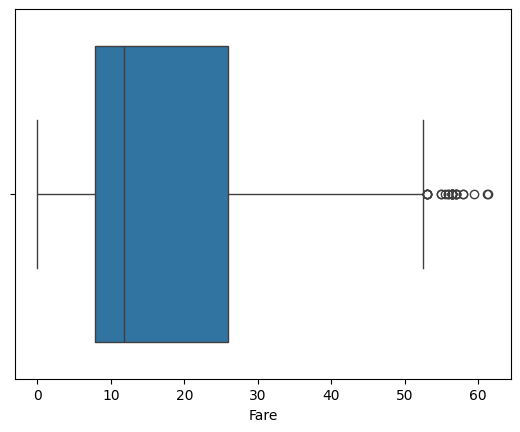

In [64]:
sns.boxplot(x=df["Fare"])
plt.show()

In [65]:
# manual encoder
df["Sex"]=df["Sex"].replace("male",0)
df["Sex"]=df["Sex"].replace("female",1)

In [66]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,Q


In [67]:
df["Embarked"].unique()

array(['S', 'Q', 'C'], dtype=object)

In [68]:
df["Embarked"]=df["Embarked"].replace("S",0)
df["Embarked"]=df["Embarked"].replace("C",1)
df["Embarked"]=df["Embarked"].replace("Q",2)

In [69]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,2


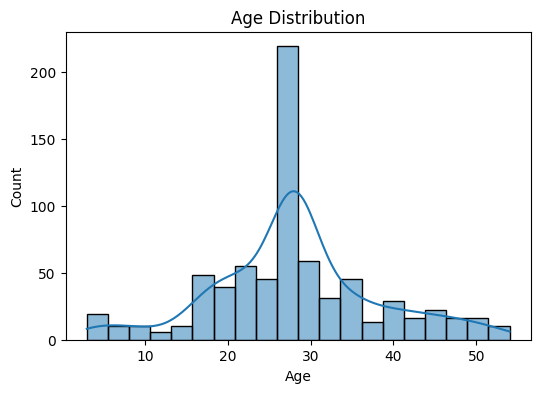

In [70]:
#univarient analysis
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],bins=20,kde=True)

plt.title("Age Distribution")
plt.show()

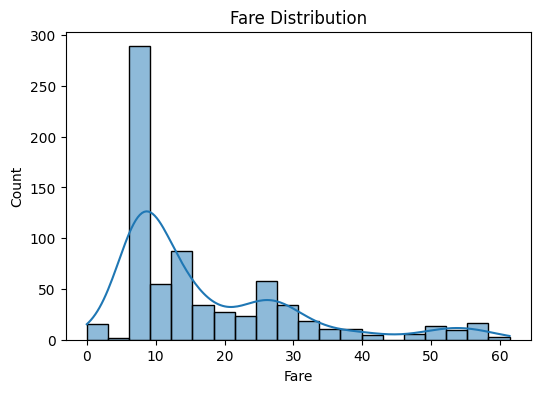

In [71]:
plt.figure(figsize=(6,4))
sns.histplot(df["Fare"],bins=20,kde=True)

plt.title("Fare Distribution")
plt.show()

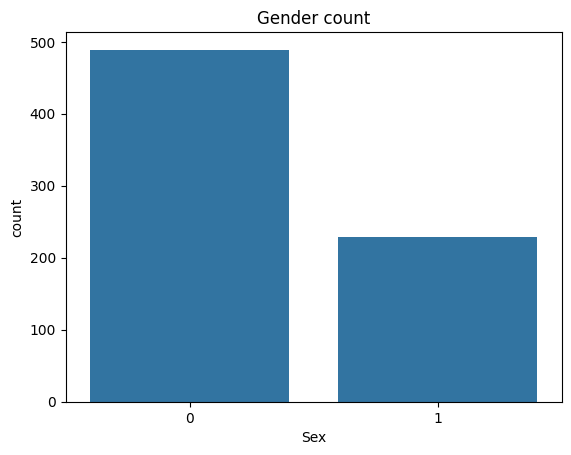

In [72]:
sns.countplot(x="Sex",data=df)
plt.title("Gender count")
plt.show()

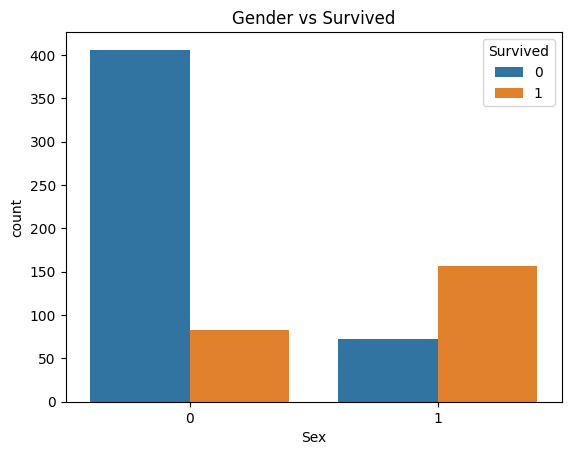

In [73]:
#bivarient analysis
sns.countplot(x="Sex",hue="Survived",data=df)
plt.title("Gender vs Survived")
plt.show()

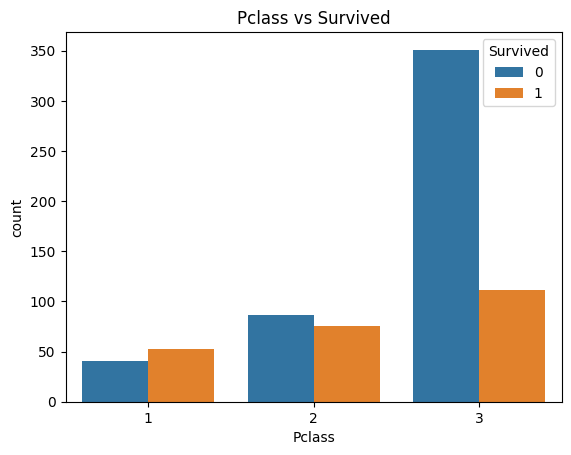

In [74]:
sns.countplot(x="Pclass",hue="Survived",data=df)
plt.title("Pclass vs Survived")
plt.show()

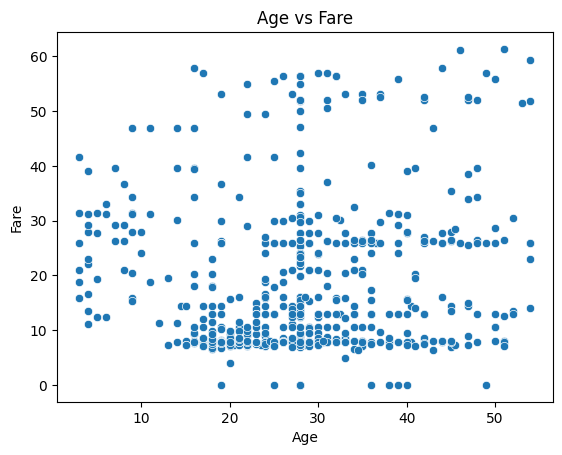

In [75]:
sns.scatterplot(x="Age",y="Fare",data=df)
plt.title("Age vs Fare")
plt.show()

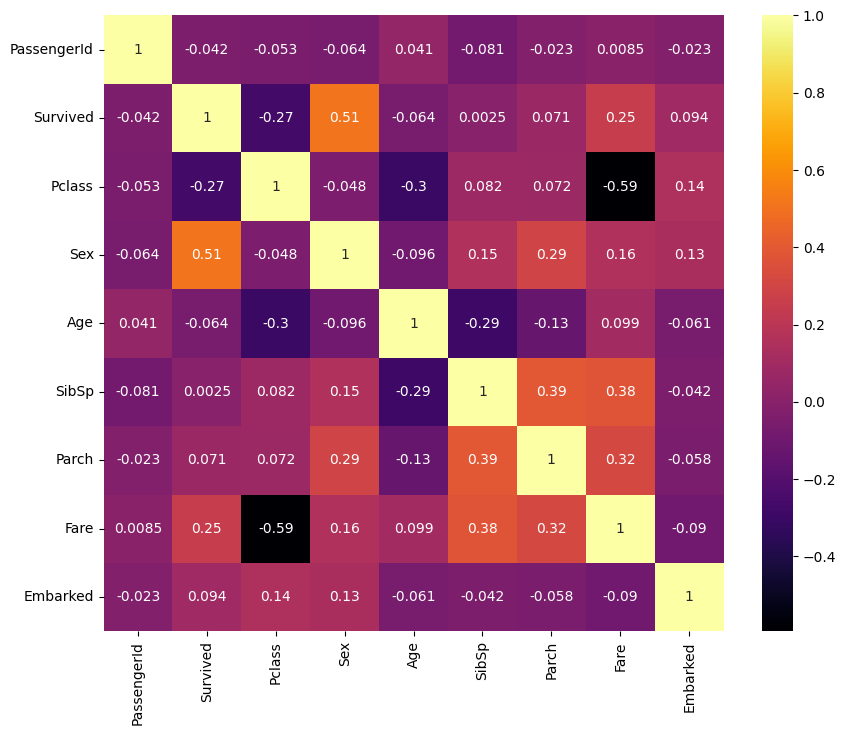

In [76]:
#multivarient
plt.figure(figsize=(10,8))

numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
                    annot=True,
                    cmap='inferno')
plt.show()

In [77]:
#Feature scaling
x=df.drop("Survived",axis=1)
y=df["Survived"]

In [78]:
X=x.drop(["PassengerId","Name","Ticket"],axis=1)

In [79]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X[["Age","Fare"]]=scaler.fit_transform(X[["Age","Fare"]])

In [80]:
X.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,-0.607611,1,0,-0.751265,0
2,3,1,-0.207827,0,0,-0.700265,0
3,1,1,0.691688,1,0,2.712961,0
4,3,0,0.691688,0,0,-0.690821,0
5,3,0,-0.007934,0,0,-0.659971,2
6,1,0,2.590664,0,0,2.619461,0
8,3,1,-0.107881,0,2,-0.457860,0
9,2,1,-1.407180,1,0,0.972975,1
10,3,1,-2.406641,1,1,-0.037264,0
12,3,0,-0.807503,0,0,-0.690821,0


In [81]:
#Train-Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [82]:
print("training data:",X_train.shape)
print("test data:",X_test.shape)

training data: (574, 7)
test data: (144, 7)


In [83]:
print(X_train.head())

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
69        3    0 -0.207827      2      0 -0.644543         0
248       1    0  0.891580      1      1  2.671722         0
403       3    0 -0.007934      1      0 -0.101487         0
662       1    0  1.891041      0      0  0.634236         0
30        1    0  1.191419      0      0  0.795419         1


In [84]:
import warnings
warnings.filterwarnings("ignore")